# Section 1.2.5 — Deuxièmes limites avec Markovian Conditional Restart Splitting

On étend le modèle aux deux premières limites de chaque côté du carnet :

$$
Q^{+1}, Q^{+2}\quad \text{côté ask},\qquad
Q^{-1}, Q^{-2}\quad \text{côté bid}.
$$

Cette version du notebook utilise la méthode demandée pour le projet :

**Markovian Conditional Restart Splitting**.

Ogata thinning reste le simulateur de trajectoires sous-jacent, mais les distributions conditionnelles affichées dans cette section sont estimées à partir de redémarrages locaux depuis des états frontière complets $(N,S)$, et non par les anciens compléments expérimentaux.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.hawkes_4q import FourQueueParams
from model import FourQueueHawkesSimulator
from model.restart_splitting import (
    METHOD_NAME,
    collect_boundary_states,
    local_depletion_target_fn,
    local_recovery_fn,
    restart_from_boundary_distribution,
    summarize_conditional_S,
    plot_conditional_S_marginals,
    plot_conditional_S_pairwise,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
QUEUE_INDICES = [1, -1, 2, -2]

BASE_CFG = dict(
    mu_plus_1=1.2,
    mu_minus_1=1.5,
    alpha=0.3,
    beta=0.5,
    mu_plus_2=0.8,
    mu_minus_2=0.6,
    b_cross=0.5,
    q1_init=10,
    q_neg1_init=10,
    q2_init=5,
    q_neg2_init=5,
)

N_BOUNDARY_PATHS = 500
N_RESTARTS = 1_500
HORIZON_BOUNDARY = 120.0
HORIZON_LOCAL = 25.0
RECOVERY_LEVEL = 2
BURN_IN = 0.0

pd.Series(BASE_CFG, name='base parameters')

mu_plus_1       1.2
mu_minus_1      1.5
alpha           0.3
beta            0.5
mu_plus_2       0.8
mu_minus_2      0.6
b_cross         0.5
q1_init        10.0
q_neg1_init    10.0
q2_init         5.0
q_neg2_init     5.0
Name: base parameters, dtype: float64

## Convention de signe et état markovien augmenté

Le code utilise l'ordre d'état suivant :

$$
[Q^{+1}, Q^{-1}, Q^{+2}, Q^{-2}].
$$

Les indices positifs correspondent au côté ask, les indices négatifs au côté bid. Dans cette section on estime explicitement :

- $Q^{-2}_{same} = Q^{-2}\mid Q^{-1}=0$ ;
- $Q^{-2}_{opp} = Q^{-2}\mid Q^{+1}=0$ ;
- $\mathrm{Law}(Q^{-2}\mid Q^{-1}=0)$ ;
- $\mathrm{Law}(Q^{-2}\mid Q^{+1}=0)$.

Pour le modèle Hawkes exponentiel, le processus est markovien si l'état contient les tailles de files $N$ et l'excitation courante $S$. Le vecteur affiché dans ce notebook est

$$
S=(S^{1,+}, S^{1,-}, S^{2,+}, S^{2,-}, S^{1,+\to 2,-}).
$$

Dans l'implémentation actuelle, ce vecteur est extrait des checkpoints comme

$$
[H_{+1}, H_{-1}, G_{+2}, G_{-2}, G_{-2}],
$$

c'est-à-dire que la cinquième composante rend explicite le canal d'excitation croisée $Q^{-1}\to Q^{-2}$ demandé pour l'interprétation.

In [2]:
def make_params(a_cross: float, q0: int = 10) -> FourQueueParams:
    return FourQueueParams(
        **dict(BASE_CFG, q1_init=q0, q_neg1_init=q0),
        a_cross=float(a_cross),
    )


def resume_distribution(x):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        'n': int(len(x)),
        'mean': float(np.mean(x)) if len(x) else np.nan,
        'std': float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        'q05': float(np.quantile(x, 0.05)) if len(x) else np.nan,
        'median': float(np.quantile(x, 0.50)) if len(x) else np.nan,
        'q95': float(np.quantile(x, 0.95)) if len(x) else np.nan,
    })


def q_label(queue_index: int) -> str:
    return 'Q+1' if queue_index == 1 else 'Q-1'


def run_mcrs_side(
    params: FourQueueParams,
    queue_index: int,
    seed: int,
    n_boundary_paths: int = N_BOUNDARY_PATHS,
    n_restarts: int = N_RESTARTS,
    horizon_boundary: float = HORIZON_BOUNDARY,
    horizon_local: float = HORIZON_LOCAL,
    recovery_level: int = RECOVERY_LEVEL,
    burn_in: float = BURN_IN,
):
    simulator = FourQueueHawkesSimulator(params)
    initial_state = [params.q1_init, params.q_neg1_init, params.q2_init, params.q_neg2_init]
    boundary_sample = collect_boundary_states(
        simulator=simulator,
        initial_state=initial_state,
        horizon=horizon_boundary,
        n_paths=n_boundary_paths,
        rng=seed,
        burn_in=burn_in,
        queue_index=queue_index,
        boundary_level=1,
        queue_indices=QUEUE_INDICES,
        boundary_name=f'{q_label(queue_index)}=1',
        queue_label=q_label(queue_index),
    )
    result = restart_from_boundary_distribution(
        checkpoints=boundary_sample,
        simulator=simulator,
        local_target_fn=local_depletion_target_fn(queue_index),
        recovery_fn=local_recovery_fn(queue_index, recovery_level),
        horizon_local=horizon_local,
        n_restarts=n_restarts,
        rng=seed + 1_000_003,
        sample_with_replacement=True,
        record_path=False,
    )
    return {
        'method': METHOD_NAME,
        'params': params,
        'queue_index': queue_index,
        'simulator': simulator,
        'boundary_sample': boundary_sample,
        'result': result,
    }


def q_neg2_success(bundle):
    return np.asarray(bundle['result'].observables.get('q_neg2_success', np.empty(0)), dtype=float)


def q_neg2_all_restarts(bundle):
    return np.asarray(bundle['result'].observables.get('q_neg2', np.empty(0)), dtype=float)


def result_row(regime, side_name, bundle):
    res = bundle['result']
    sample = bundle['boundary_sample']
    q = q_neg2_success(bundle)
    ci = res.confidence_interval if res.confidence_interval is not None else (np.nan, np.nan)
    stats = resume_distribution(q)
    return {
        'regime': regime,
        'side': side_name,
        'method': res.method_name,
        'probability': res.probability_estimate,
        'std_error': res.standard_error,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'n_boundary_paths': sample.metadata['n_paths'],
        'n_boundary_samples': sample.metadata['n_boundary_hits'],
        'n_restarts': res.n_restarts,
        'n_successes': res.n_successes,
        'mean_Q-2_success': stats['mean'],
        'q05_Q-2_success': stats['q05'],
        'median_Q-2_success': stats['median'],
        'q95_Q-2_success': stats['q95'],
        'cpu_restart_seconds': res.diagnostics.get('cpu_seconds', np.nan),
        'n_events_restart': res.diagnostics.get('n_events', np.nan),
        'n_candidates_restart': res.diagnostics.get('n_candidates', np.nan),
    }


def conditional_S_table(sample):
    names = sample.metadata.get('S_component_names', [])
    summary = summarize_conditional_S(sample.S_samples, names)
    if not names:
        return pd.DataFrame({'n_samples': [summary['n_samples']]})
    rows = []
    for j, name in enumerate(names):
        rows.append({
            'component': name,
            'mean': summary['mean'][j],
            'std': summary['std'][j],
            'q05': summary['quantiles'][0.05][j],
            'median': summary['quantiles'][0.50][j],
            'q95': summary['quantiles'][0.95][j],
        })
    return pd.DataFrame(rows).set_index('component')


def restart_content_table(bundle, n=10):
    res = bundle['result']
    obs = res.observables
    start_q = obs['start_queues']
    final_q = obs['final_queues']
    start_S = obs['start_S']
    end_S = obs['end_S']
    success = obs['success']
    local_times = obs['local_times']
    names = bundle['boundary_sample'].metadata.get('S_component_names', [])
    rows = []
    for k in range(min(n, len(success))):
        row = {
            'restart': k,
            'success': bool(success[k]),
            'local_time': local_times[k],
            'start_Q+1': start_q[k, 0],
            'start_Q-1': start_q[k, 1],
            'start_Q-2': start_q[k, 3],
            'final_Q+1': final_q[k, 0],
            'final_Q-1': final_q[k, 1],
            'final_Q-2': final_q[k, 3],
        }
        for j, name in enumerate(names):
            row[f'start {name}'] = start_S[k, j]
            row[f'end {name}'] = end_S[k, j]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_q_neg2_overlay(data, title):
    max_value = 10
    for values, _label in data:
        if len(values):
            max_value = max(max_value, int(np.max(values)))
    bins = np.arange(-0.5, max_value + 1.5, 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    for values, label in data:
        if len(values):
            ax.hist(values, bins=bins, density=True, alpha=0.45, label=label)
    ax.set_xlabel(r'$Q^{-2}$ at local depletion')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.legend()
    plt.show()


def plot_restart_scatter(bundle, title):
    res = bundle['result']
    obs = res.observables
    start_S = obs['start_S']
    final_q = obs['final_queues']
    success = obs['success']
    names = bundle['boundary_sample'].metadata.get('S_component_names', [])
    cross_idx = names.index('S^{1,+ -> 2,-}') if 'S^{1,+ -> 2,-}' in names else start_S.shape[1] - 1
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(start_S[:, cross_idx], final_q[:, 3], c=success, cmap='coolwarm', alpha=0.55, s=18)
    ax.set_xlabel(r'start $S^{1,+\to 2,-}$')
    ax.set_ylabel(r'final $Q^{-2}$')
    ax.set_title(title)
    plt.show()


## Collecte de checkpoints frontière et loi conditionnelle de $S$

On collecte d'abord des trajectoires jusqu'à la première atteinte d'une frontière proche de la déplétion :

$$Q^{-1}=1\quad\text{ou}\quad Q^{+1}=1.$$

Chaque checkpoint contient le temps, les quatre queues, l'intensité courante et le vecteur d'excitation $S$. Les graphiques ci-dessous visualisent les lois empiriques

$$\mathrm{Law}(S\mid Q^{-1}=1),\qquad \mathrm{Law}(S\mid Q^{+1}=1).$$

In [3]:
params_const = make_params(a_cross=0.0)
params_exc = make_params(a_cross=0.5)

mcrs_const_same = run_mcrs_side(params_const, queue_index=-1, seed=SEED + 10)
mcrs_const_opp = run_mcrs_side(params_const, queue_index=1, seed=SEED + 20)

boundary_overview = pd.DataFrame([
    result_row('a=0', 'Q-1 boundary -> Q-2 same', mcrs_const_same),
    result_row('a=0', 'Q+1 boundary -> Q-2 opp', mcrs_const_opp),
])
display(boundary_overview)

display(pd.concat({
    'Law(S | Q-1=1)': conditional_S_table(mcrs_const_same['boundary_sample']),
    'Law(S | Q+1=1)': conditional_S_table(mcrs_const_opp['boundary_sample']),
}))


,regime,side,method,probability,std_error,ci_low,ci_high,n_boundary_paths,n_boundary_samples,n_restarts,n_successes,mean_Q-2_success,q05_Q-2_success,median_Q-2_success,q95_Q-2_success,cpu_restart_seconds,n_events_restart,n_candidates_restart
0,a=0,Q-1 boundary -> Q-2 same,Markovian Conditional Restart Splitting,0.795333,0.010417,0.774916,0.815751,500,500,1500,1193,6.088852,2.0,6.0,11.0,0.135792,3117,3187
1,a=0,Q+1 boundary -> Q-2 opp,Markovian Conditional Restart Splitting,0.810667,0.010116,0.790840,0.830493,500,500,1500,1216,5.922697,2.0,6.0,10.0,0.137566,3266,3336


mean       std       q05    median  \
               component                                                
Law(S | Q-1=1) S^{1,+}         3.722460  0.948236  2.220153  3.661055   
               S^{1,-}         3.919049  0.854145  2.547194  3.858383   
               S^{2,+}         0.000000  0.000000  0.000000  0.000000   
               S^{2,-}         0.000000  0.000000  0.000000  0.000000   
               S^{1,+ -> 2,-}  0.000000  0.000000  0.000000  0.000000   
Law(S | Q+1=1) S^{1,+}         3.833977  0.799836  2.525872  3.786909   
               S^{1,-}         3.588976  1.004244  1.985433  3.603938   
               S^{2,+}         0.000000  0.000000  0.000000  0.000000   
               S^{2,-}         0.000000  0.000000  0.000000  0.000000   
               S^{1,+ -> 2,-}  0.000000  0.000000  0.000000  0.000000   

                                    q95  
               component                 
Law(S | Q-1=1) S^{1,+}         5.376778  
               S^{1,-}         5.356567  
               S^{2,+}         0.000000  
               S^{2,-}         0.000000  
               S^{1,+ -> 2,-}  0.000000  
Law(S | Q+1=1) S^{1,+}         5.142460  
               S^{1,-}         5.266265  
               S^{2,+}         0.000000  
               S^{2,-}         0.000000  
               S^{1,+ -> 2,-}  0.000000

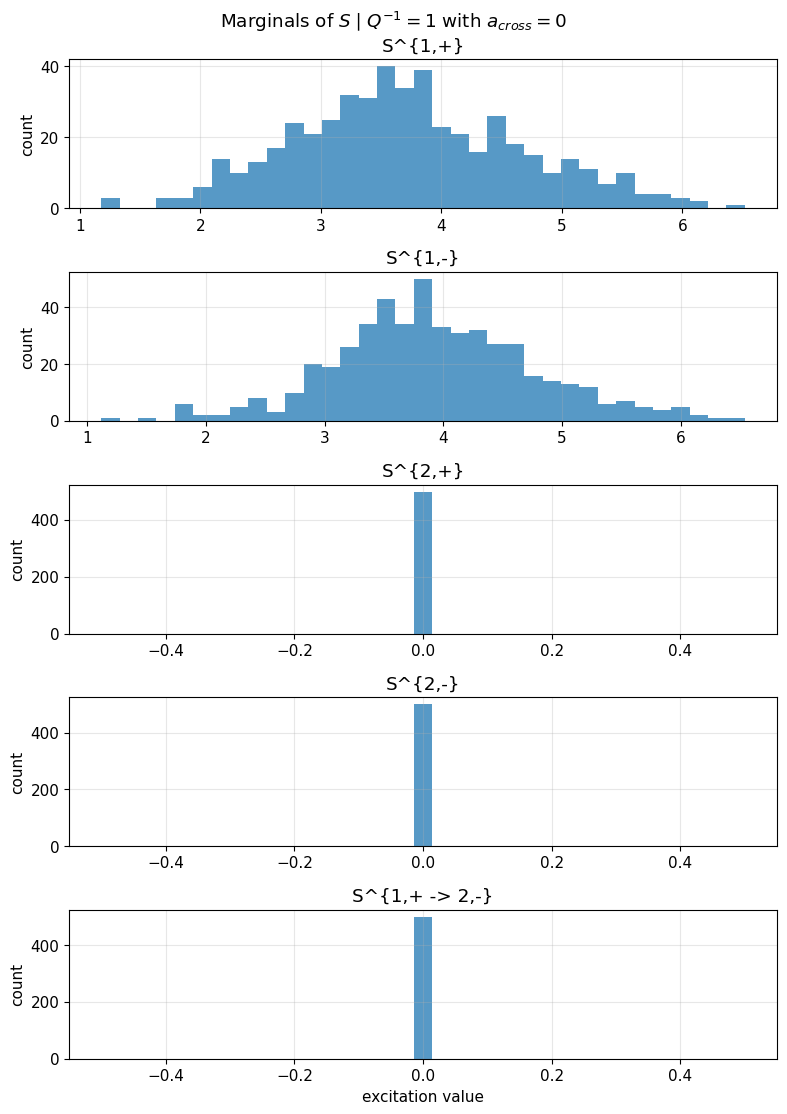

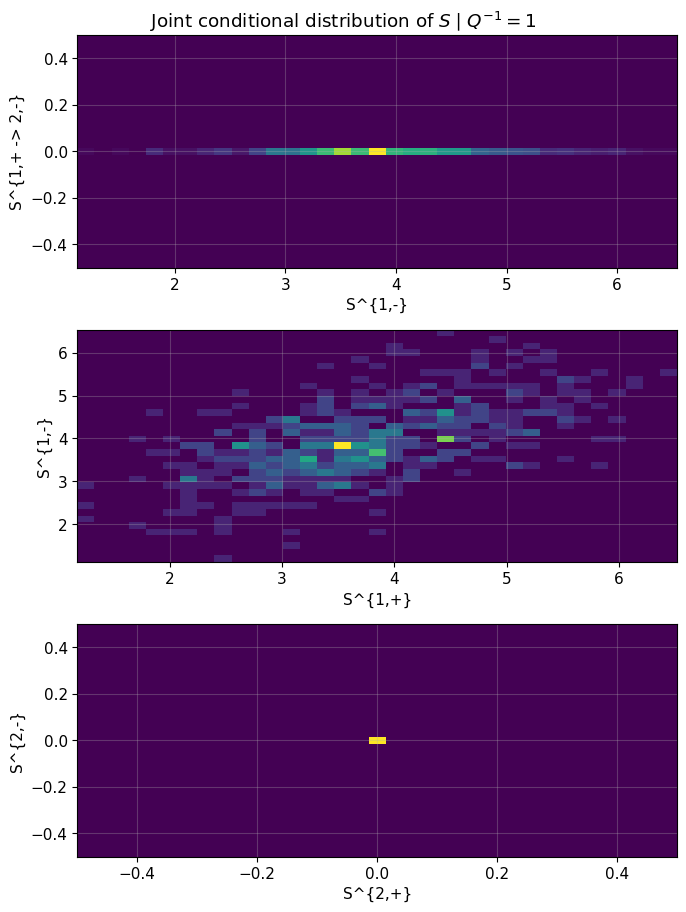

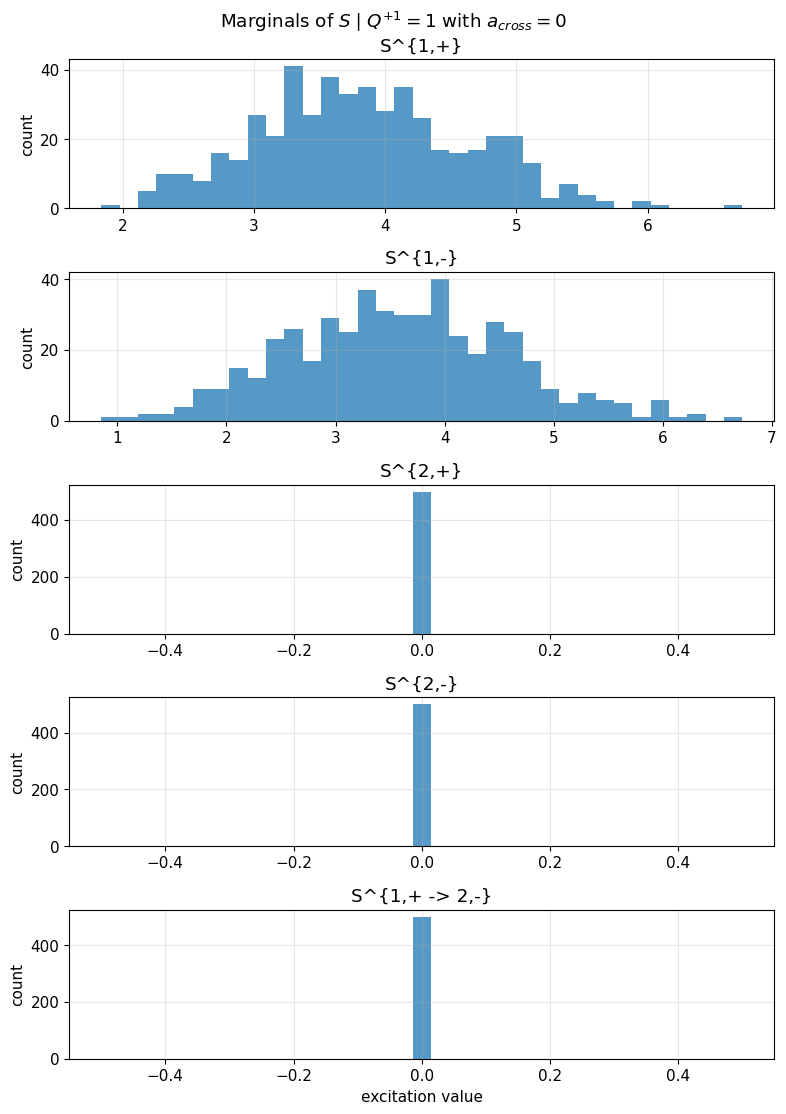

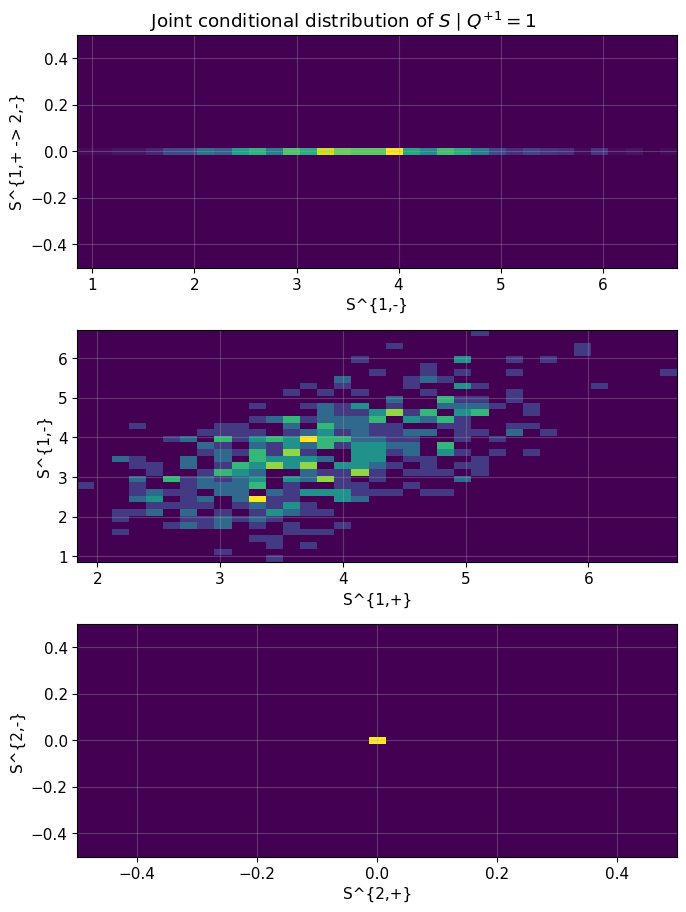

In [4]:
names_same = mcrs_const_same['boundary_sample'].metadata['S_component_names']
names_opp = mcrs_const_opp['boundary_sample'].metadata['S_component_names']

fig, _ = plot_conditional_S_marginals(mcrs_const_same['boundary_sample'].S_samples, names_same, bins=35)
fig.suptitle(r'Marginals of $S\mid Q^{-1}=1$ with $a_{cross}=0$', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    mcrs_const_same['boundary_sample'].S_samples,
    names_same,
    pairs=[(1, 4), (0, 1), (2, 3)],
    bins=35,
)
fig.suptitle(r'Joint conditional distribution of $S\mid Q^{-1}=1$', y=1.01)
plt.show()

fig, _ = plot_conditional_S_marginals(mcrs_const_opp['boundary_sample'].S_samples, names_opp, bins=35)
fig.suptitle(r'Marginals of $S\mid Q^{+1}=1$ with $a_{cross}=0$', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    mcrs_const_opp['boundary_sample'].S_samples,
    names_opp,
    pairs=[(1, 4), (0, 1), (2, 3)],
    bins=35,
)
fig.suptitle(r'Joint conditional distribution of $S\mid Q^{+1}=1$', y=1.01)
plt.show()


## Question 1.2.5.1 — Deuxièmes limites sans excitation croisée

On fixe $a_{cross}=0$. Les deuxièmes limites n'ont pas d'excitation croisée active. Les quantités ci-dessous sont estimées par redémarrage MCRS depuis la frontière, puis continuation locale jusqu'à :

- succès : la première limite ciblée touche zéro ;
- récupération : la première limite ciblée remonte à $2$ ;
- arrêt : l'horizon local est atteint.

Les histogrammes utilisent seulement les redémarrages réussis.

,n,mean,std,q05,median,q95
Q-2_same = Q-2 | Q-1=0,1193.0,6.088852,2.708826,2.0,6.0,11.0
Q-2_opp = Q-2 | Q+1=0,1216.0,5.922697,2.441199,2.0,6.0,10.0


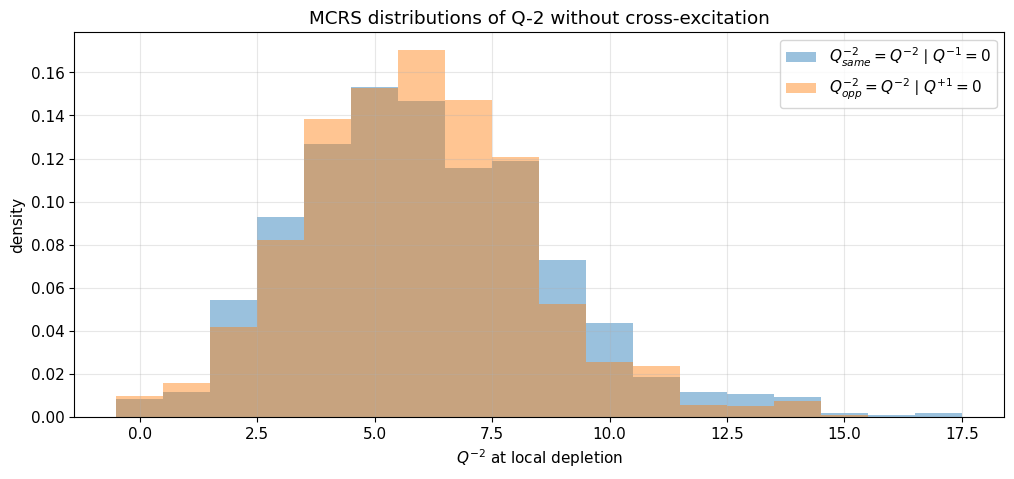

In [5]:
q_neg2_same_const = q_neg2_success(mcrs_const_same)
q_neg2_opp_const = q_neg2_success(mcrs_const_opp)

q2_const_table = pd.DataFrame({
    'Q-2_same = Q-2 | Q-1=0': resume_distribution(q_neg2_same_const),
    'Q-2_opp = Q-2 | Q+1=0': resume_distribution(q_neg2_opp_const),
}).T

display(q2_const_table)

plot_q_neg2_overlay(
    [
        (q_neg2_same_const, r'$Q^{-2}_{same}=Q^{-2}\mid Q^{-1}=0$'),
        (q_neg2_opp_const, r'$Q^{-2}_{opp}=Q^{-2}\mid Q^{+1}=0$'),
    ],
    'MCRS distributions of Q-2 without cross-excitation',
)


## Contenu des redémarrages MCRS

Cette table montre concrètement ce qui est redémarré : on échantillonne un checkpoint frontière complet, avec les queues et le vecteur $S$, puis on simule localement depuis cet état. C'est cette partie qui distingue Markovian Conditional Restart Splitting d'un redémarrage incorrect depuis la seule taille de queue.

,restart,success,local_time,start_Q+1,start_Q-1,start_Q-2,final_Q+1,final_Q-1,final_Q-2,"start S^{1,+}","end S^{1,+}","start S^{1,-}","end S^{1,-}","start S^{2,+}","end S^{2,+}","start S^{2,-}","end S^{2,-}","start S^{1,+ -> 2,-}","end S^{1,+ -> 2,-}"
0,0,True,0.065216,0.0,1.0,9.0,0.0,0.0,9.0,3.499831,3.687548,3.858110,4.034333,0.0,0.0,0.0,0.0,0.0,0.0
1,1,True,0.117363,5.0,1.0,3.0,6.0,0.0,3.0,5.223350,4.931629,6.135884,6.380209,0.0,0.0,0.0,0.0,0.0,0.0
2,2,True,0.036303,5.0,1.0,9.0,5.0,0.0,9.0,4.085048,4.311568,3.852199,4.082907,0.0,0.0,0.0,0.0,0.0,0.0
3,3,True,0.166709,1.0,1.0,4.0,1.0,0.0,4.0,3.741634,3.742396,3.992826,3.973499,0.0,0.0,0.0,0.0,0.0,0.0
4,4,True,0.563003,2.0,1.0,7.0,2.0,0.0,7.0,2.614288,2.272872,3.801599,3.168876,0.0,0.0,0.0,0.0,0.0,0.0
5,5,True,0.073960,5.0,1.0,6.0,5.0,0.0,5.0,2.702747,2.904625,2.710549,2.912143,0.0,0.0,0.0,0.0,0.0,0.0
6,6,True,0.068216,7.0,1.0,0.0,6.0,0.0,0.0,3.875156,4.338417,4.488207,4.930910,0.0,0.0,0.0,0.0,0.0,0.0
7,7,True,0.001280,4.0,1.0,8.0,4.0,0.0,8.0,4.742712,5.039677,4.536681,4.833778,0.0,0.0,0.0,0.0,0.0,0.0


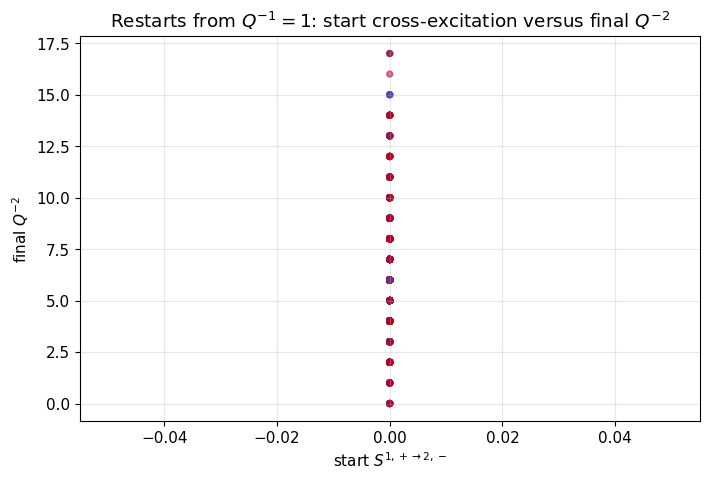

In [6]:
display(restart_content_table(mcrs_const_same, n=8))
plot_restart_scatter(
    mcrs_const_same,
    r'Restarts from $Q^{-1}=1$: start cross-excitation versus final $Q^{-2}$',
)


## Question 1.2.5.2 — Excitation croisée et effet même côté

On active maintenant le canal d'excitation croisée avec $a_{cross}=0.5$. Dans le code, les removals de $Q^{-1}$ alimentent $G_{-2}$, donc le composant $S^{1,+\to 2,-}$ affiché dans le notebook suit le canal $Q^{-1}\to Q^{-2}$.

,regime,side,method,probability,std_error,ci_low,ci_high,n_boundary_paths,n_boundary_samples,n_restarts,n_successes,mean_Q-2_success,q05_Q-2_success,median_Q-2_success,q95_Q-2_success,cpu_restart_seconds,n_events_restart,n_candidates_restart
0,a=0.5,Q-1 boundary -> Q-2 same,Markovian Conditional Restart Splitting,0.814000,0.010047,0.794308,0.833692,500,500,1500,1221,13.241605,6.0,12.0,24.0,0.174132,4626,4724
1,a=0.5,Q+1 boundary -> Q-2 opp,Markovian Conditional Restart Splitting,0.808667,0.010156,0.788760,0.828573,500,500,1500,1213,12.773289,5.0,12.0,24.0,0.176145,4602,4694


,n,mean,std,q05,median,q95
"Q-2_same, a=0",1193.0,6.088852,2.708826,2.0,6.0,11.0
"Q-2_same, a=0.5",1221.0,13.241605,5.638111,6.0,12.0,24.0
"Q-2_opp, a=0",1216.0,5.922697,2.441199,2.0,6.0,10.0
"Q-2_opp, a=0.5",1213.0,12.773289,6.054664,5.0,12.0,24.0


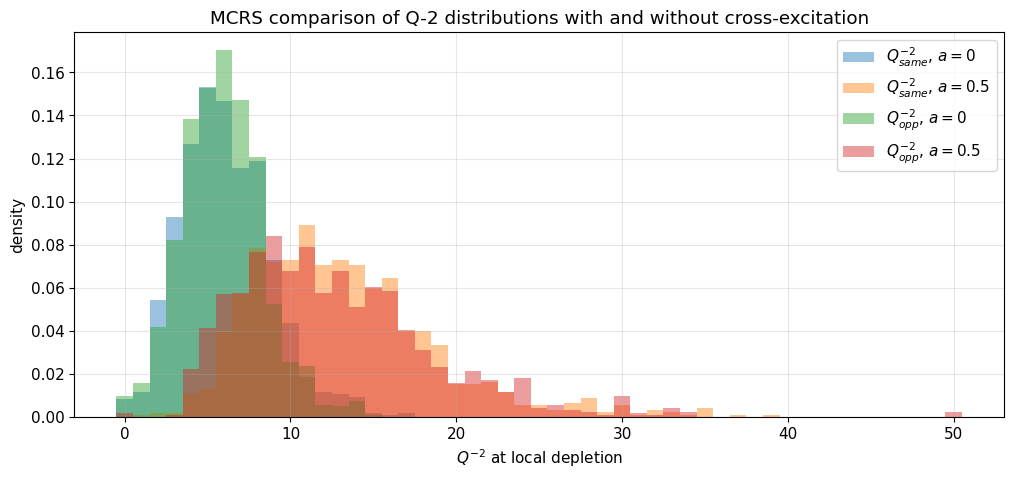

In [7]:
mcrs_exc_same = run_mcrs_side(params_exc, queue_index=-1, seed=SEED + 30)
mcrs_exc_opp = run_mcrs_side(params_exc, queue_index=1, seed=SEED + 40)

q_neg2_same_exc = q_neg2_success(mcrs_exc_same)
q_neg2_opp_exc = q_neg2_success(mcrs_exc_opp)

comparison_exc_table = pd.DataFrame([
    result_row('a=0.5', 'Q-1 boundary -> Q-2 same', mcrs_exc_same),
    result_row('a=0.5', 'Q+1 boundary -> Q-2 opp', mcrs_exc_opp),
])
display(comparison_exc_table)

display(pd.DataFrame({
    'Q-2_same, a=0': resume_distribution(q_neg2_same_const),
    'Q-2_same, a=0.5': resume_distribution(q_neg2_same_exc),
    'Q-2_opp, a=0': resume_distribution(q_neg2_opp_const),
    'Q-2_opp, a=0.5': resume_distribution(q_neg2_opp_exc),
}).T)

plot_q_neg2_overlay(
    [
        (q_neg2_same_const, r'$Q^{-2}_{same}$, $a=0$'),
        (q_neg2_same_exc, r'$Q^{-2}_{same}$, $a=0.5$'),
        (q_neg2_opp_const, r'$Q^{-2}_{opp}$, $a=0$'),
        (q_neg2_opp_exc, r'$Q^{-2}_{opp}$, $a=0.5$'),
    ],
    'MCRS comparison of Q-2 distributions with and without cross-excitation',
)


,restart,success,local_time,start_Q+1,start_Q-1,start_Q-2,final_Q+1,final_Q-1,final_Q-2,"start S^{1,+}","end S^{1,+}","start S^{1,-}","end S^{1,-}","start S^{2,+}","end S^{2,+}","start S^{2,-}","end S^{2,-}","start S^{1,+ -> 2,-}","end S^{1,+ -> 2,-}"
0,0,True,0.067200,5.0,1.0,8.0,5.0,0.0,8.0,2.951778,3.154246,3.832355,4.005727,2.580897,2.495620,3.072547,3.471024,3.072547,3.471024
1,1,True,0.404210,11.0,1.0,7.0,8.0,0.0,8.0,1.834255,2.592176,2.924956,3.483289,0.921808,2.075747,3.044201,2.987140,3.044201,2.987140
2,2,True,1.275891,0.0,1.0,20.0,0.0,0.0,23.0,3.093711,1.964165,3.033009,2.819108,1.161829,1.402264,3.943771,2.583797,3.943771,2.583797
3,3,True,0.086808,1.0,1.0,11.0,0.0,0.0,11.0,3.967258,4.398323,3.992346,4.422344,3.052644,3.422275,3.580359,3.928281,3.580359,3.928281
4,4,True,0.049068,0.0,1.0,15.0,0.0,0.0,15.0,2.844741,3.075798,3.785641,3.993895,2.836241,2.767504,2.689078,3.123907,2.689078,3.123907
5,5,True,0.305975,5.0,1.0,13.0,5.0,0.0,13.0,3.480306,3.286590,4.546097,4.201189,3.131289,2.687085,3.557380,3.552731,3.557380,3.552731
6,6,True,0.003134,7.0,1.0,8.0,7.0,0.0,8.0,2.927914,3.223330,3.739302,4.033447,2.185035,2.181614,3.370978,3.865700,3.370978,3.865700
7,7,True,0.256894,5.0,1.0,14.0,4.0,0.0,16.0,3.917818,4.015287,4.577809,5.194052,3.164369,3.731082,3.915321,3.943368,3.915321,3.943368


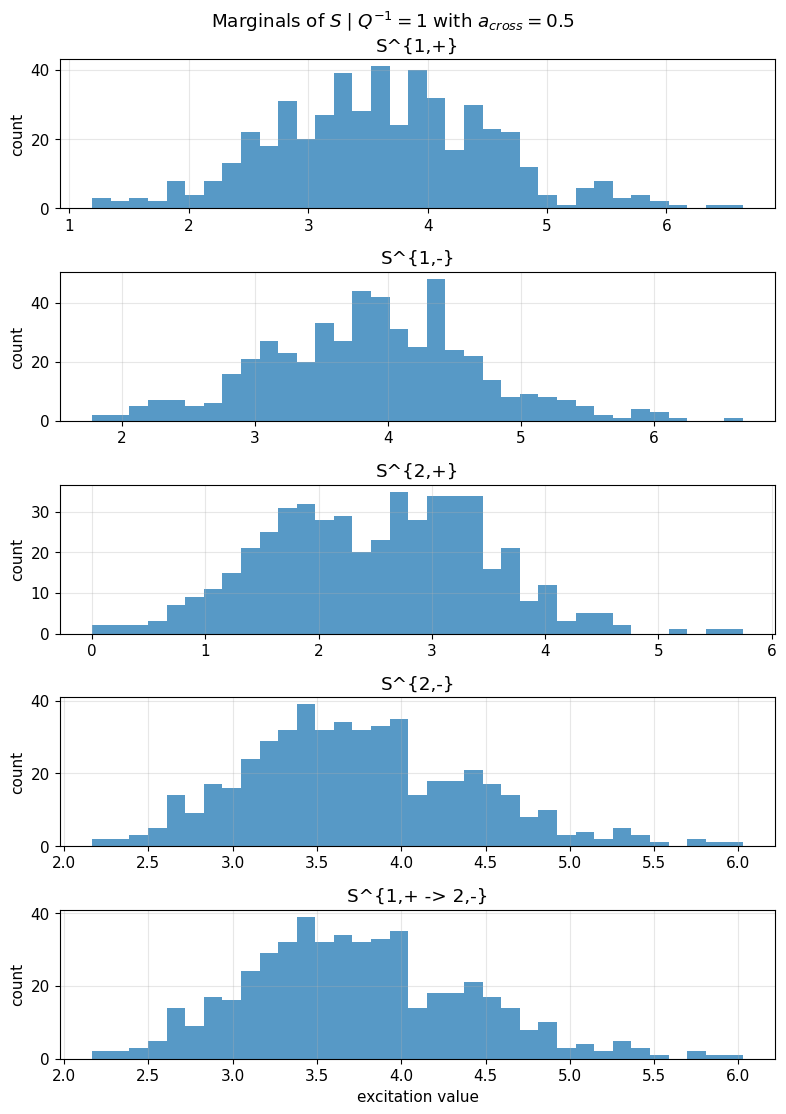

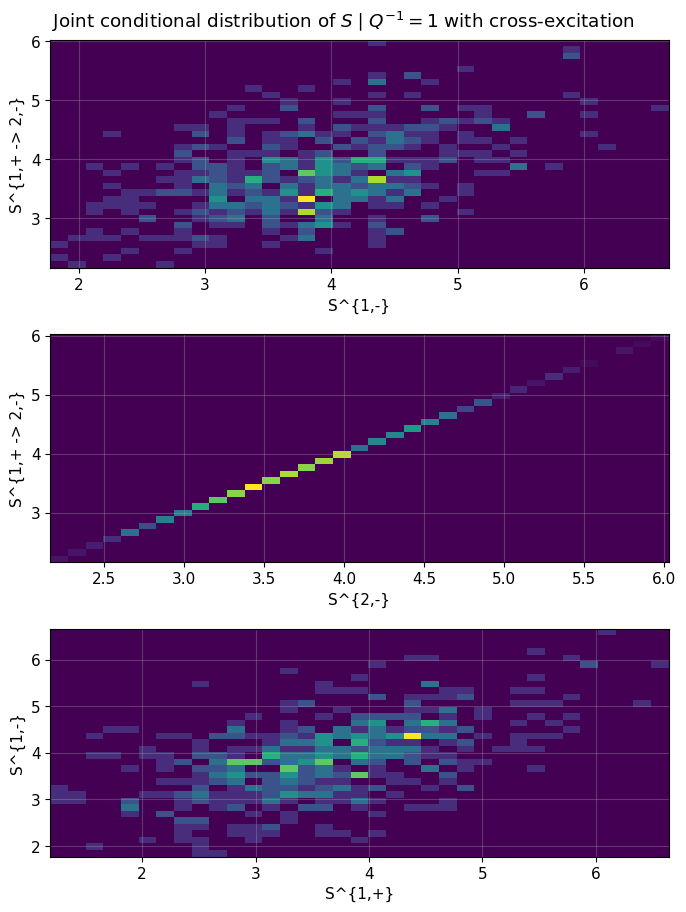

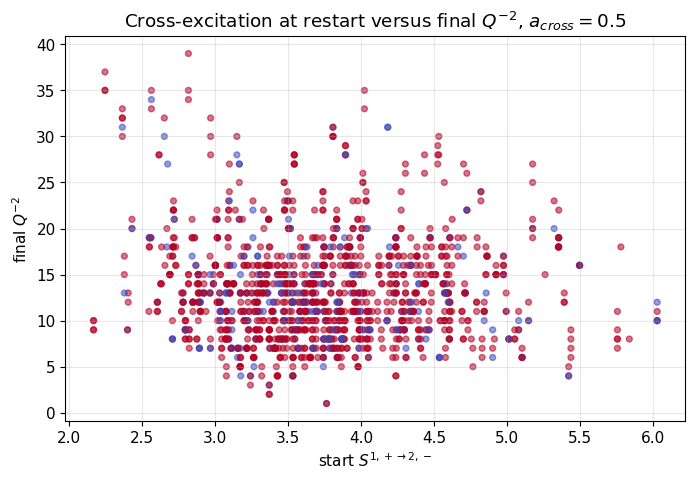

In [8]:
display(restart_content_table(mcrs_exc_same, n=8))

names_exc = mcrs_exc_same['boundary_sample'].metadata['S_component_names']
fig, _ = plot_conditional_S_marginals(mcrs_exc_same['boundary_sample'].S_samples, names_exc, bins=35)
fig.suptitle(r'Marginals of $S\mid Q^{-1}=1$ with $a_{cross}=0.5$', y=1.01)
plt.show()

fig, _ = plot_conditional_S_pairwise(
    mcrs_exc_same['boundary_sample'].S_samples,
    names_exc,
    pairs=[(1, 4), (3, 4), (0, 1)],
    bins=35,
)
fig.suptitle(r'Joint conditional distribution of $S\mid Q^{-1}=1$ with cross-excitation', y=1.01)
plt.show()

plot_restart_scatter(
    mcrs_exc_same,
    r'Cross-excitation at restart versus final $Q^{-2}$, $a_{cross}=0.5$',
)


## Diagnostic : préserver $S$ est indispensable

On redémarre depuis les mêmes checkpoints frontière, une fois avec le vrai $S$ empirique, une fois après remise à zéro artificielle de $S$. Le second cas est mathématiquement incorrect pour Hawkes ; il sert uniquement à montrer que l'état augmenté $(N,S)$ porte de l'information.

In [9]:
reset_result_same = restart_from_boundary_distribution(
    checkpoints=mcrs_exc_same['boundary_sample'],
    simulator=mcrs_exc_same['simulator'],
    local_target_fn=local_depletion_target_fn(-1),
    recovery_fn=local_recovery_fn(-1, RECOVERY_LEVEL),
    horizon_local=HORIZON_LOCAL,
    n_restarts=N_RESTARTS,
    rng=SEED + 50,
    sample_with_replacement=True,
    reset_excitation=True,
)

correct = mcrs_exc_same['result']
reset_q = np.asarray(reset_result_same.observables.get('q_neg2_success', np.empty(0)), dtype=float)

diagnostic_reset = pd.DataFrame([
    {
        'restart': 'correct empirical S',
        'probability': correct.probability_estimate,
        'std_error': correct.standard_error,
        'mean_start_cross_S': correct.observables['start_S'][:, -1].mean(),
        'mean_Q-2_success': q_neg2_success(mcrs_exc_same).mean(),
        'n_successes': correct.n_successes,
    },
    {
        'restart': 'S reset to zero',
        'probability': reset_result_same.probability_estimate,
        'std_error': reset_result_same.standard_error,
        'mean_start_cross_S': reset_result_same.observables['start_S'][:, -1].mean(),
        'mean_Q-2_success': reset_q.mean() if len(reset_q) else np.nan,
        'n_successes': reset_result_same.n_successes,
    },
])
display(diagnostic_reset)


,restart,probability,std_error,mean_start_cross_S,mean_Q-2_success,n_successes
0,correct empirical S,0.814,0.010047,3.742583,13.241605,1221
1,S reset to zero,0.572,0.012775,0.000000,12.810023,858


## Analyse de sensibilité en fonction de $a_{cross}$

On balaie

$$a_{cross}\in\{0,0.1,0.3,0.5,1.0\}.$$

Pour chaque valeur, on estime par MCRS les deux distributions conditionnelles demandées :

$$Q^{-2}\mid Q^{-1}=0,\qquad Q^{-2}\mid Q^{+1}=0.$$

In [10]:
a_cross_values = [0.0, 0.1, 0.3, 0.5, 1.0]
sensitivity = []
sensitivity_bundles = {}

for i, a in enumerate(a_cross_values):
    params = make_params(a_cross=a)
    same = run_mcrs_side(
        params,
        queue_index=-1,
        seed=SEED + 1_000 + 17 * i,
        n_boundary_paths=300,
        n_restarts=900,
    )
    opp = run_mcrs_side(
        params,
        queue_index=1,
        seed=SEED + 2_000 + 17 * i,
        n_boundary_paths=300,
        n_restarts=900,
    )
    sensitivity_bundles[a] = {'same': same, 'opp': opp}
    q_same = q_neg2_success(same)
    q_opp = q_neg2_success(opp)
    sensitivity.append({
        'a_cross': a,
        'P(Q-1=0 before recovery | Q-1=1)': same['result'].probability_estimate,
        'P(Q+1=0 before recovery | Q+1=1)': opp['result'].probability_estimate,
        'SE_same': same['result'].standard_error,
        'SE_opp': opp['result'].standard_error,
        'E[Q-2_same]': np.mean(q_same) if len(q_same) else np.nan,
        'E[Q-2_opp]': np.mean(q_opp) if len(q_opp) else np.nan,
        'q05_same': np.quantile(q_same, 0.05) if len(q_same) else np.nan,
        'q95_same': np.quantile(q_same, 0.95) if len(q_same) else np.nan,
        'q05_opp': np.quantile(q_opp, 0.05) if len(q_opp) else np.nan,
        'q95_opp': np.quantile(q_opp, 0.95) if len(q_opp) else np.nan,
        'boundary_samples_same': same['boundary_sample'].metadata['n_boundary_hits'],
        'boundary_samples_opp': opp['boundary_sample'].metadata['n_boundary_hits'],
        'successes_same': same['result'].n_successes,
        'successes_opp': opp['result'].n_successes,
    })

sensitivity_table = pd.DataFrame(sensitivity)
display(sensitivity_table)


,a_cross,P(Q-1=0 before recovery | Q-1=1),P(Q+1=0 before recovery | Q+1=1),SE_same,SE_opp,E[Q-2_same],E[Q-2_opp],q05_same,q95_same,q05_opp,q95_opp,boundary_samples_same,boundary_samples_opp,successes_same,successes_opp
0,0.0,0.830000,0.813333,0.012521,0.012988,6.190094,5.721311,2.0,10.0,1.55,10.0,300,300,747,732
1,0.1,0.796667,0.817778,0.013416,0.012868,7.350070,7.047554,3.0,13.0,2.75,12.0,300,300,717,736
2,0.3,0.804444,0.804444,0.013221,0.013221,9.767956,10.284530,5.0,16.0,4.00,18.0,300,300,724,724
3,0.5,0.825556,0.796667,0.012650,0.013416,12.908479,13.556485,5.1,24.0,5.00,25.0,300,300,743,717
4,1.0,0.801111,0.797778,0.013305,0.013389,20.545076,20.860724,9.0,39.0,6.85,37.0,300,300,721,718


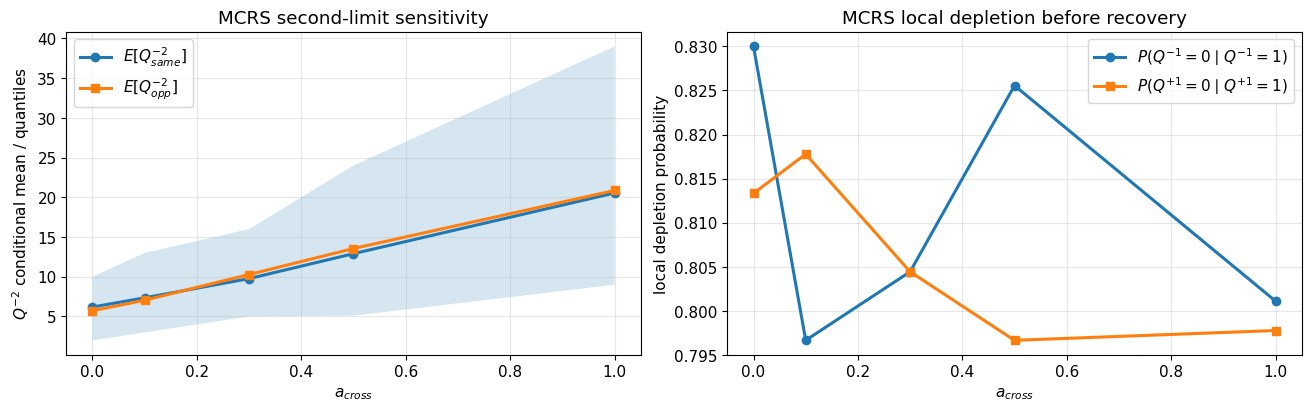

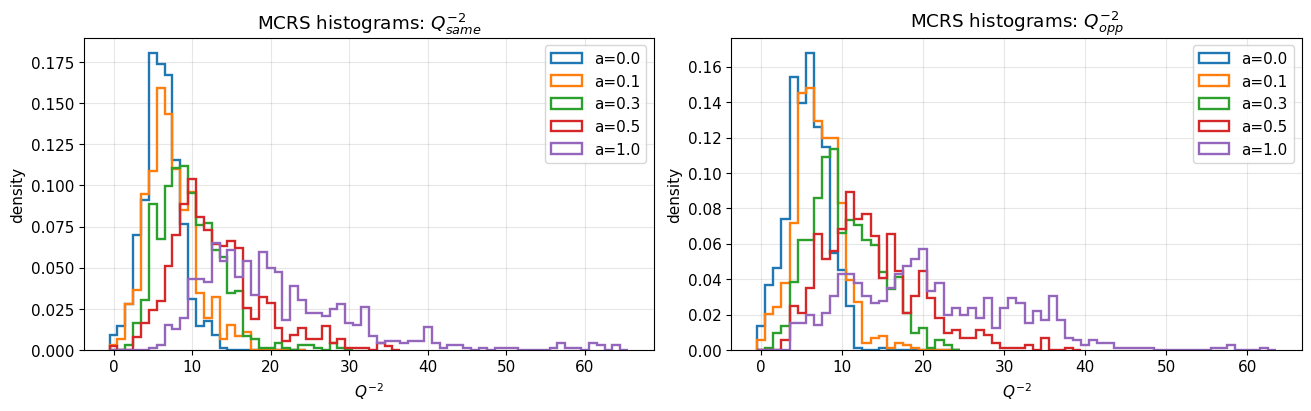

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
axes[0].plot(sensitivity_table['a_cross'], sensitivity_table['E[Q-2_same]'], marker='o', linewidth=2.2, label=r'$E[Q^{-2}_{same}]$')
axes[0].plot(sensitivity_table['a_cross'], sensitivity_table['E[Q-2_opp]'], marker='s', linewidth=2.2, label=r'$E[Q^{-2}_{opp}]$')
axes[0].fill_between(sensitivity_table['a_cross'], sensitivity_table['q05_same'], sensitivity_table['q95_same'], alpha=0.18)
axes[0].set_xlabel(r'$a_{cross}$')
axes[0].set_ylabel(r'$Q^{-2}$ conditional mean / quantiles')
axes[0].set_title('MCRS second-limit sensitivity')
axes[0].legend()

axes[1].plot(
    sensitivity_table['a_cross'],
    sensitivity_table['P(Q-1=0 before recovery | Q-1=1)'],
    marker='o',
    linewidth=2.2,
    label=r'$P(Q^{-1}=0\mid Q^{-1}=1)$',
)
axes[1].plot(
    sensitivity_table['a_cross'],
    sensitivity_table['P(Q+1=0 before recovery | Q+1=1)'],
    marker='s',
    linewidth=2.2,
    label=r'$P(Q^{+1}=0\mid Q^{+1}=1)$',
)
axes[1].set_xlabel(r'$a_{cross}$')
axes[1].set_ylabel('local depletion probability')
axes[1].set_title('MCRS local depletion before recovery')
axes[1].legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout='constrained')
for a, bundle in sensitivity_bundles.items():
    q_same = q_neg2_success(bundle['same'])
    if len(q_same):
        axes[0].hist(q_same, bins=np.arange(-0.5, max(25, int(q_same.max()) + 2), 1), density=True, histtype='step', linewidth=1.7, label=f'a={a}')
    q_opp = q_neg2_success(bundle['opp'])
    if len(q_opp):
        axes[1].hist(q_opp, bins=np.arange(-0.5, max(25, int(q_opp.max()) + 2), 1), density=True, histtype='step', linewidth=1.7, label=f'a={a}')
axes[0].set_title(r'MCRS histograms: $Q^{-2}_{same}$')
axes[1].set_title(r'MCRS histograms: $Q^{-2}_{opp}$')
for ax in axes:
    ax.set_xlabel(r'$Q^{-2}$')
    ax.set_ylabel('density')
    ax.legend()
plt.show()


## Conclusion

Les distributions conditionnelles de la deuxième limite sont maintenant obtenues par **Markovian Conditional Restart Splitting**. La méthode exploite les états frontière empiriques $Q^{-1}=1$ et $Q^{+1}=1$, conserve le vecteur d'excitation Hawkes $S$, puis redémarre localement jusqu'à déplétion ou récupération.

La comparaison avec le redémarrage incorrect où $S$ est remis à zéro montre pourquoi l'état augmenté $(N,S)$ est nécessaire : pour un modèle Hawkes, la queue seule n'est pas un état markovien suffisant.